# Quadratic Programming: Mean-Variance Portfolio Optimization

## Problem

Given `n` assets with expected-return vector `mu` and covariance matrix `Sigma`, the Markowitz
mean-variance problem finds the minimum-variance portfolio for a target expected return
`r_target`:

```
minimize    (1/2) w^T Sigma w
subject to  w^T mu = r_target
            w^T 1  = 1
```

This is a quadratic program (QP) with linear equality constraints — no inequality constraints
(short selling allowed). Sweeping `r_target` traces the classical efficient frontier
(Markowitz, 1952).

## Method

The Lagrangian is `L(w, lambda) = (1/2) w^T Sigma w - lambda^T (A w - b)`, with
`A = [mu^T; 1^T]` and `b = [r_target; 1]`. Stationarity gives the KKT linear system

```
[ Sigma   -A^T ] [ w      ]   [ 0 ]
[ A        0   ] [ lambda ] = [ b ]
```

which is assembled explicitly and solved with a single dense linear solve — no calls to a
general-purpose QP or optimization routine. Solving this system once per `r_target` gives the
efficient frontier directly (no iteration needed, since the equality-constrained QP has a
closed-form linear solution).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Five synthetic assets: annualized expected returns and volatilities, with a documented
# correlation structure (positive-definite by construction).
mu = np.array([0.08, 0.12, 0.10, 0.14, 0.09])
vol = np.array([0.15, 0.22, 0.18, 0.28, 0.16])
corr = np.array([
    [1.00, 0.30, 0.20, 0.10, 0.25],
    [0.30, 1.00, 0.25, 0.15, 0.20],
    [0.20, 0.25, 1.00, 0.20, 0.10],
    [0.10, 0.15, 0.20, 1.00, 0.05],
    [0.25, 0.20, 0.10, 0.05, 1.00],
])
Sigma = np.outer(vol, vol) * corr
n = len(mu)

def min_variance_portfolio(r_target):
    """Solve the equality-constrained QP via the dense KKT system."""
    A = np.vstack([mu, np.ones(n)])
    b = np.array([r_target, 1.0])
    KKT = np.zeros((n + 2, n + 2))
    KKT[:n, :n] = Sigma
    KKT[:n, n:] = -A.T
    KKT[n:, :n] = A
    rhs = np.zeros(n + 2)
    rhs[n:] = b
    sol = np.linalg.solve(KKT, rhs)
    return sol[:n]

print(f"{'r_target':>10} {'std_dev':>10} {'sum(w)':>10} {'w.mu':>10}   weights")
for r_target in np.linspace(mu.min(), mu.max(), 8):
    w = min_variance_portfolio(r_target)
    variance = w @ Sigma @ w
    print(f"{r_target:10.4f} {np.sqrt(variance):10.4f} {w.sum():10.6f} {w @ mu:10.6f}   {np.round(w, 3)}")


  r_target    std_dev     sum(w)       w.mu   weights
    0.0800     0.1230   1.000000   0.080000   [ 0.58  -0.109  0.231 -0.065  0.363]
    0.0886     0.1093   1.000000   0.088571   [ 0.431 -0.012  0.226  0.02   0.336]
    0.0971     0.1065   1.000000   0.097143   [0.282 0.085 0.221 0.104 0.308]
    0.1057     0.1153   1.000000   0.105714   [0.132 0.183 0.216 0.188 0.281]
    0.1143     0.1335   1.000000   0.114286   [-0.017  0.28   0.211  0.272  0.254]
    0.1229     0.1579   1.000000   0.122857   [-0.166  0.377  0.206  0.357  0.227]
    0.1314     0.1860   1.000000   0.131429   [-0.315  0.474  0.201  0.441  0.2  ]
    0.1400     0.2164   1.000000   0.140000   [-0.465  0.572  0.196  0.525  0.172]


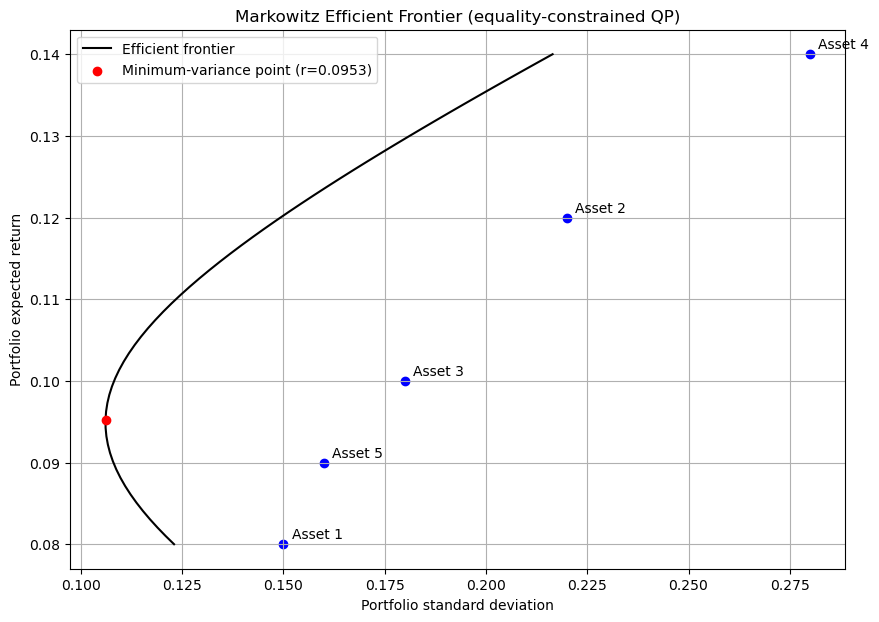

Minimum-variance portfolio: r = 0.0953, std = 0.1061


In [2]:
# Efficient frontier: target return vs. minimum achievable standard deviation
r_grid = np.linspace(mu.min(), mu.max(), 60)
std_grid = np.empty_like(r_grid)
for i, r_target in enumerate(r_grid):
    w = min_variance_portfolio(r_target)
    std_grid[i] = np.sqrt(w @ Sigma @ w)

min_idx = np.argmin(std_grid)

plt.figure(figsize=(10, 7))
plt.plot(std_grid, r_grid, color='black', label='Efficient frontier')
plt.scatter(std_grid[min_idx], r_grid[min_idx], color='red', zorder=5,
            label=f'Minimum-variance point (r={r_grid[min_idx]:.4f})')
for i in range(n):
    plt.scatter(vol[i], mu[i], color='blue')
    plt.annotate(f'Asset {i+1}', (vol[i], mu[i]), textcoords="offset points", xytext=(6, 4))
plt.xlabel('Portfolio standard deviation')
plt.ylabel('Portfolio expected return')
plt.title('Markowitz Efficient Frontier (equality-constrained QP)')
plt.grid(True)
plt.legend()
plt.show()

print(f"Minimum-variance portfolio: r = {r_grid[min_idx]:.4f}, std = {std_grid[min_idx]:.4f}")


## Notes

The frontier is a parabola in variance (a hyperbola in standard-deviation/return space), as
expected from the closed-form solution of an equality-constrained quadratic form. Every point on
it is the exact solution of a linear system — no iterative solver, tolerance, or convergence
criterion is involved for this equality-only case. The `interior-point-method` notebook in this
repository revisits the same asset set with an added `w >= 0` constraint, which does require an
iterative method.